In [1]:
from datasets import load_dataset, DatasetDict, Dataset
from torch.utils.data import DataLoader
from PIL import Image
import utils as ut
import torch

2024-08-19 12:02:19.335627: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-19 12:02:19.366049: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-19 12:02:19.366072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-19 12:02:19.366864: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-19 12:02:19.371938: I tensorflow/core/platform/cpu_feature_guar

In [5]:
def cut_align(image, line, show=False):
    """
    Given an image and line annotation from the dataset, 
    remove background, segment, rotate and cut the two halves.
    Returns halves from the same angle.
    """
    edge_points = ut.non_zeros(image, plot=False)
    transparent_img = ut.segment2(image, edge_points)
    rotated_img = ut.rotate(transparent_img, line, show_line=False)
    slice1, slice2 = ut.slice_aligned(rotated_img)
    slice1 = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)
    slice1, slice2 = slice1.resize((224, 224)), slice2.resize((224, 224))

    if show:
        display(slice1) # bottom half
        display(slice2) # top

    return slice1, slice2

def transforms(examples):
    # careful with the conversion here, resize migth be needed on other datasets
    list_slices = [cut_align(im.convert("L"), line) for im, line in zip(examples["image"], examples["line"])]
    examples["slice1"], examples["slice2"] = [i[0] for i in list_slices], [i[1] for i in list_slices]
    # examples["image_convert"] = [image.convert("L").resize((290, 290)) for image in examples["image"]]

    return examples

In [6]:
hf_dataset = load_dataset("agucci/mri-sym2")

def siamese_noise_dataset(test_size=0.2, shuffle=False):
    """
    T1 only here
    """
    # T1 
    dst1 = hf_dataset['train'].map(transforms, batched=True)
    # noise every other sample
    noise_slice1_t1 = [ut.add_noise(im, rgb=True) if i%2 else im for i, im in enumerate(dst1['slice1'])]
    labels_t1 = [1 if i%2 else 0 for i in range(len(dst1['slice1']))]

    dst1_ = Dataset.from_dict({
        'slice1': noise_slice1_t1,
        'slice2': dst1['slice2'],
        'label': labels_t1
    })

    # splits 
    dst1_traintestval = dst1_.train_test_split(test_size=test_size, shuffle = shuffle)
    dst1_testval = dst1_traintestval['test'].train_test_split(test_size=0.5, shuffle = False)

    dst1_final = DatasetDict({
        'train': dst1_traintestval['train'],
        'test': dst1_testval['test'],
        'valid': dst1_testval['train']})

    return dst1_final

In [7]:
ds_1 = siamese_noise_dataset(shuffle=False)

Map:   0%|          | 0/1476 [00:00<?, ? examples/s]

In [8]:
ds_1

DatasetDict({
    train: Dataset({
        features: ['slice1', 'slice2', 'label'],
        num_rows: 1180
    })
    test: Dataset({
        features: ['slice1', 'slice2', 'label'],
        num_rows: 148
    })
    valid: Dataset({
        features: ['slice1', 'slice2', 'label'],
        num_rows: 148
    })
})

In [9]:
ds_1['train']

Dataset({
    features: ['slice1', 'slice2', 'label'],
    num_rows: 1180
})

## Network

In [10]:
from __future__ import print_function
import argparse, time, pickle

import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms as T
from torch.optim.lr_scheduler import StepLR

In [77]:
class SiameseNetworkResnet(nn.Module):
    """
        Siamese network for image similarity estimation.
        The network is composed of two identical networks, one for each input.
        The output of each network is concatenated and passed to a linear layer. 
        The output of the linear layer passed through a sigmoid function.
        The `ResNet-18` model is the feature extractor.
    """
    def __init__(self):
        super(SiameseNetworkResnet, self).__init__()
        # get resnet model
        # self.resnet = torchvision.models.resnet18(weights=None)
        self.resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights)

        # over-write the first conv layer to be able to read MNIST images
        # as resnet18 reads (3,x,x) where 3 is RGB channels
        # whereas MNIST has (1,x,x) where 1 is a gray-scale channel
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.fc_in_features = self.resnet.fc.in_features
        
        # remove the last layer of resnet18 (linear layer which is before avgpool layer)
        self.resnet = torch.nn.Sequential(*(list(self.resnet.children())[:-1]))

        # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_in_features * 2, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1),
        )

        self.sigmoid = nn.Sigmoid()

        # initialize the weights
        self.resnet.apply(self.init_weights)
        self.fc.apply(self.init_weights)
        
    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def forward_once(self, x):
        output = self.resnet(x)
        output = output.view(output.size()[0], -1)
        return output

    def forward(self, input1, input2):
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)

        # pass the out of the linear layers to sigmoid layer
        output = self.sigmoid(output)
        
        return output

In [11]:
device = torch.device("cuda")

train_loader = DataLoader(ds_1['train'].with_format("torch"), batch_size=32)
test_loader = DataLoader(ds_1['test'].with_format("torch"), batch_size=32)

In [12]:
ds_1['train']

Dataset({
    features: ['slice1', 'slice2', 'label'],
    num_rows: 1180
})

In [ ]:
next(iter(train_loader))['slice1']

In [13]:
[i for i in train_loader][0]['slice1'].shape

torch.Size([32, 224, 224])

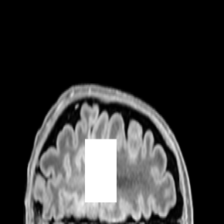

In [21]:
import torchvision.transforms as T

T.Resize((224,224))(T.ToPILImage()([i for i in train_loader][0]['slice1'][1]))

In [ ]:
([i for i in train_loader][0])

## 2

In [2]:
# MRI DATA
print("Loading data, might take a few minutes the first time")
ds_1 = ut.siamese_noise_dataset(shuffle=False, resize=True)
train_loader = torch.utils.data.DataLoader(ds_1['train'].with_format("torch"), batch_size=32)
test_loader = torch.utils.data.DataLoader(ds_1['test'].with_format("torch"), batch_size=32)
print("Data load completed")
print(f"{len(train_loader)}, {len(test_loader)}")

Loading data, might take a few minutes the first time
Data load completed
37, 5


In [3]:
next(iter(train_loader))['label'].shape

torch.Size([32])

In [4]:
slice1 = ds_1['train'].with_format("torch")[0]['slice1']
slice2 = ds_1['train'].with_format("torch")[0]['slice2']
label = ds_1['train'].with_format("torch")[0]['label']

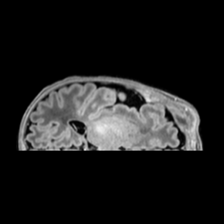

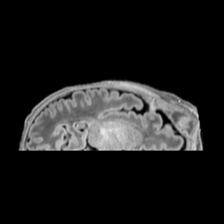

In [5]:
from torchvision.transforms import functional as F

display(F.to_pil_image(slice1))
F.to_pil_image(slice2)

In [6]:
37*32, 5*32
# ds_1

(1184, 160)

In [5]:
import matplotlib.pyplot as plt

def plot_batch_mosaic(images_1, images_2, targets):
    images_1 = images_1.squeeze().cpu().numpy()
    images_2 = images_2.squeeze().cpu().numpy()
    targets = targets.cpu().numpy()

    # Create an 8x8 grid (64 images total)
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    fig.suptitle("Batch Mosaic: Slice1 and Slice2 with Labels", fontsize=16)

    for i in range(32):
        row = i // 4
        col = (i % 4) * 2
        
        # Plot slice1
        axes[row, col].imshow(images_1[i], cmap='gray')
        axes[row, col].axis('off')
        axes[row, col].set_title("Left")
        
        # Plot slice2
        axes[row, col + 1].imshow(images_2[i], cmap='gray')
        axes[row, col + 1].axis('off')
        axes[row, col + 1].set_title("Right")
        
        # Add label between the two slices
        fig.text((col + 0.5) / 8, (row + 1) / 8, f"Label: {targets[i]:.2f}", 
                 ha='center', va='top', fontsize=10, transform=fig.transFigure)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

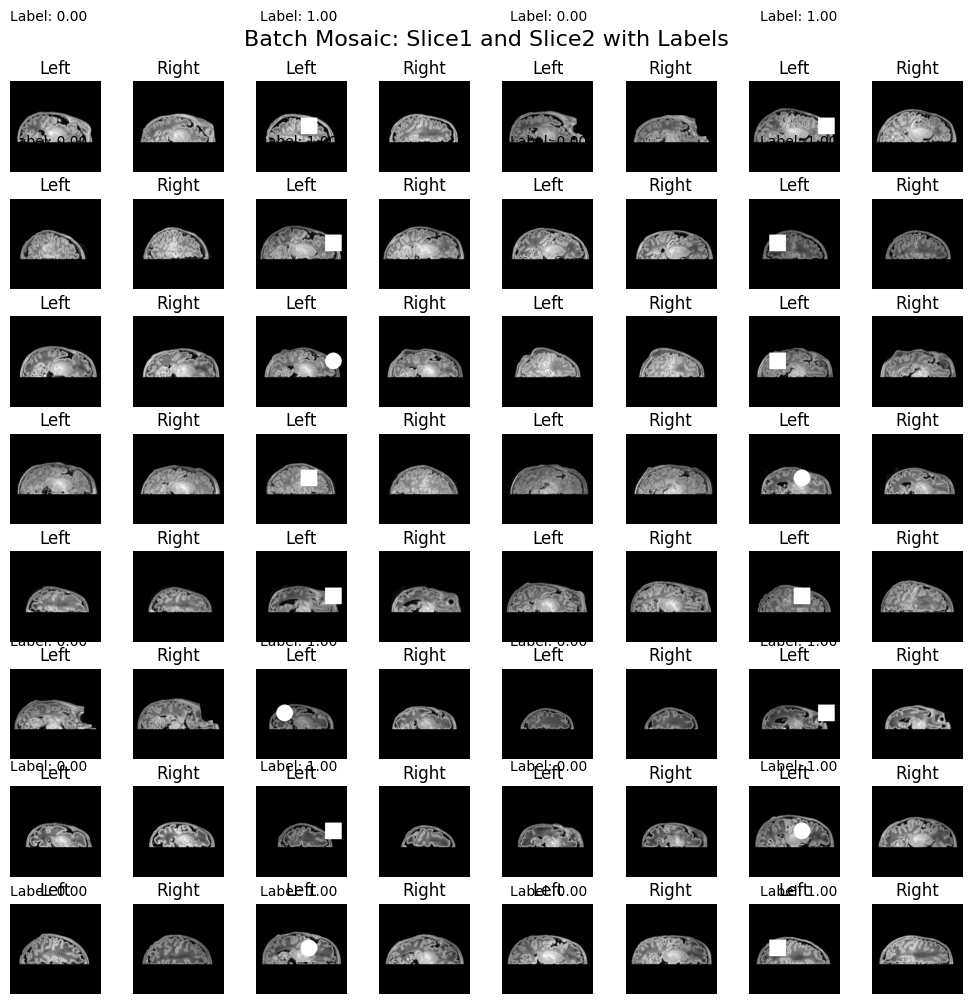

In [16]:
device = torch.device("cuda")
i = next(iter(train_loader))

images_1 = i['slice1'].to(device, dtype=torch.float32).unsqueeze(1) #[32, 224, 224]
images_2 = i['slice2'].to(device, dtype=torch.float32).unsqueeze(1) #[32, 224, 224]
targets = i['label'].to(device, dtype=torch.float32)                #[32]

plot_batch_mosaic(images_1, images_2, targets)

### t1 + t2

In [1]:
from datasets import load_dataset, DatasetDict, Dataset
from torch.utils.data import DataLoader
from PIL import Image
import utils as ut
import torch

2024-08-19 12:08:55.561356: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-19 12:08:55.591111: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-19 12:08:55.591137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-19 12:08:55.591900: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-19 12:08:55.597059: I tensorflow/core/platform/cpu_feature_guar

In [9]:
# MRI DATA
print("Loading data, might take a few minutes the first time")
ds = ut.siamese_noise_dataset_new(shuffle=False, noise_size='lil', t1=True, t2=True)
train_loader = torch.utils.data.DataLoader(ds['train'].with_format("torch"), batch_size=32)
test_loader = torch.utils.data.DataLoader(ds['test'].with_format("torch"), batch_size=32)
print("Data load completed")
print(f"{len(train_loader)}, {len(test_loader)}")

Loading data, might take a few minutes the first time
Data load completed
79, 10


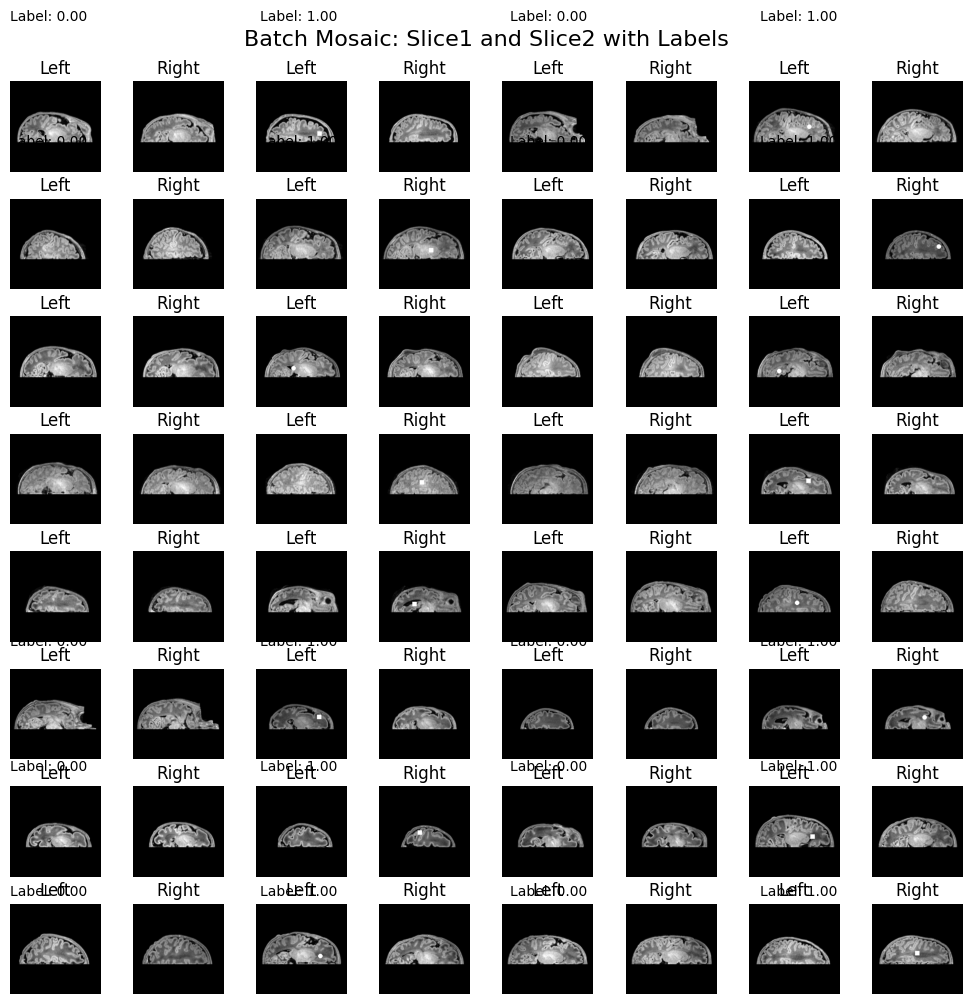

In [10]:
device = torch.device("cuda")
i = next(iter(train_loader))

images_1 = i['slice1'].to(device, dtype=torch.float32).unsqueeze(1) #[32, 224, 224]
images_2 = i['slice2'].to(device, dtype=torch.float32).unsqueeze(1) #[32, 224, 224]
targets = i['label'].to(device, dtype=torch.float32)                #[32]

plot_batch_mosaic(images_1, images_2, targets)

In [13]:
def transforms(examples):
    """
    Convert to grayscale, and map cut_align to hf dataset, add column for each half
    """
    # careful with the conversion here, resize migth be needed on other datasets
    list_slices = [cut_align(im.convert("L"), line, resize=True) for im, line in zip(examples["image"], examples["line"])]
    examples["slice1"], examples["slice2"] = [i[0] for i in list_slices], [i[1] for i in list_slices]
    # examples["image_convert"] = [image.convert("L").resize((290, 290)) for image in examples["image"]]

    return examples

In [4]:
hf_dataset = load_dataset("agucci/mri-sym2")
dst1 = hf_dataset['train'].map(ut.transforms, batched=True)

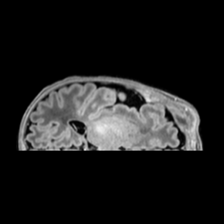

In [10]:
[i for i in (dst1)][0]['slice1']

In [6]:
def train(args, model, device, train_loader, optimizer, epoch):
    model.train()
    # we are using `BCELoss` 
    criterion = nn.BCELoss()

    for batch_idx, i in enumerate(train_loader):
        images_1 = i['slice1'].to(device, dtype=torch.float32).unsqueeze(1)
        images_2 = i['slice2'].to(device, dtype=torch.float32).unsqueeze(1)
        targets = i['label'].to(device, dtype=torch.float32)

        optimizer.zero_grad()
        outputs = model(images_1, images_2).squeeze()
        train_loss = criterion(outputs, targets)
        train_loss.backward()
        optimizer.step()

        correct = 0
        pred = torch.where(outputs > 0.5, 1, 0)  # get the index of the max log-probability
        correct += pred.eq(targets.view_as(pred)).sum().item()
        train_acc = 100. * correct / len(images_1) # 64 batch size

        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\t Accuracy: ({:.0f}%)'.format(
                epoch, batch_idx * len(images_1), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), train_loss.item(), train_acc))
            if args.dry_run:
                break

    return train_loss, train_acc

In [6]:
# MRI DATA
print("Loading data, might take a few minutes the first time")
ds_1 = ut.siamese_noise_dataset(shuffle=False, resize=False)
train_loader = torch.utils.data.DataLoader(ds_1['train'].with_format("torch"), batch_size=32)
test_loader = torch.utils.data.DataLoader(ds_1['test'].with_format("torch"), batch_size=32)
print("Data load completed")

Loading data, might take a few minutes the first time
Data load completed


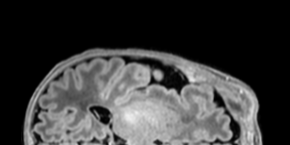

In [7]:
slice1 = ds_1['train'].with_format("torch")[0]['slice1']
slice2 = ds_1['train'].with_format("torch")[0]['slice2']
label = ds_1['train'].with_format("torch")[0]['label']


display(F.to_pil_image(slice1))
im = F.to_pil_image(slice2).resize((224,112))
# im.thumbnail((500,500), Image.LANCZOS)
im.save("im.jpg")

In [8]:
hf_dataset = load_dataset("agucci/mri-sym2")

In [9]:
image, line = hf_dataset['train'][1]['image'], hf_dataset['train'][1]['line']

In [10]:
edge_points = ut.non_zeros(image, plot=False)
transparent_img = ut.segment2(image, edge_points)
rotated_img = ut.rotate(transparent_img, line, show_line=False)
slice1, slice2 = ut.slice_aligned(rotated_img)
slice1 = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)

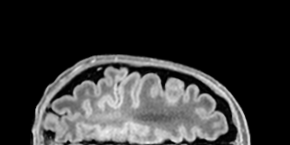

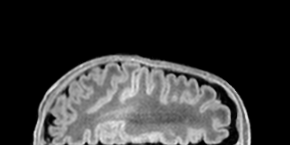

In [11]:
display(slice1 )
slice2

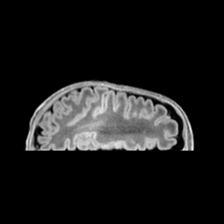

In [12]:
# Create a new image with the calculated dimensions
s = Image.new('L', (290, 290), 0)
s.paste(slice2, (0, 50))
s.resize((224,224))

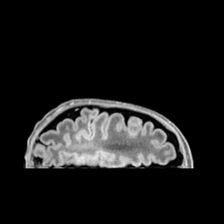

In [23]:
from PIL import Image

def extend_image(image_path, top, right, bottom, left, color=(0)):
    # Open the original image
    original = image_path
    # Get the original image dimensions
    width, height = original.size
    
    # Calculate the new dimensions
    new_width = width + left + right
    new_height = height + top + bottom
    
    # Create a new image with the calculated dimensions
    new_image = Image.new('L', (new_width, new_height), color)
    
    # Paste the original image onto the new image
    new_image.paste(original, (left, top))
    
    return new_image

# Example usage

extended_image = extend_image(slice1, top=73, right=0, bottom=72, left=0)
extended_image.resize((224, 224))

###

In [5]:

def cut_align(image, line, resize=True, show=False):
    """
    Given an image and line annotation from the dataset, 
    remove background, segment, rotate and cut the two halves.
    Returns halves from the same angle.
    """
    edge_points = ut.non_zeros(image, plot=False)
    transparent_img = ut.segment2(image, edge_points)
    rotated_img = ut.rotate(transparent_img, line, show_line=False)
    slice1, slice2 = ut.slice_aligned(rotated_img)
    slice1 = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)
    square1, square2 = Image.new('L', (290, 290), 0), Image.new('L', (290, 290), 0) # center slice in black square
    square1.paste(slice1, (0, 50)), square2.paste(slice2, (0, 50))

    if resize:
        square1, square2 = square1.resize((224, 224)), square2.resize((224, 224))

    # if show:
    #     display(slice1) # bottom half
    #     display(slice2) # top

    return square1, square2

def transforms(examples):
    """
    Convert to grayscale, and map cut_align to hf dataset, add column for each half
    """
    # careful with the conversion here, resize migth be needed on other datasets
    list_slices = [cut_align(im.convert("L"), line, resize=True) for im, line in zip(examples["image"], examples["line"])]
    examples["slice1"], examples["slice2"] = [i[0] for i in list_slices], [i[1] for i in list_slices]
    # examples["image_convert"] = [image.convert("L").resize((290, 290)) for image in examples["image"]]

    return examples

def transforms_noresize(examples):
    """
    transforms without resizing, temptative
    """
    # careful with the conversion here, resize migth be needed on other datasets
    list_slices = [cut_align(im.convert("L"), line, resize=False) for im, line in zip(examples["image"], examples["line"])]
    examples["slice1"], examples["slice2"] = [i[0] for i in list_slices], [i[1] for i in list_slices]
    # examples["image_convert"] = [image.convert("L").resize((290, 290)) for image in examples["image"]]

    return examples

hf_dataset = load_dataset("agucci/mri-sym2")

def siamese_noise_dataset(test_size=0.2, shuffle=False, resize=True):
    """
    T1 only here
    using the huggingface API for pytorch port
    """
    # T1 
    if resize:
        dst1 = hf_dataset['train'].map(transforms, batched=True)
    else:
        dst1 = hf_dataset['train'].map(transforms_noresize, batched=True)
    # noise every other sample
    noise_slice1_t1 = [ut.add_noise(im, rgb=True) if i%2 else im for i, im in enumerate(dst1['slice1'])]
    labels_t1 = [1 if i%2 else 0 for i in range(len(dst1['slice1']))]

    dst1_ = Dataset.from_dict({
        'slice1': noise_slice1_t1,
        'slice2': dst1['slice2'],
        'label': labels_t1
    })

    # splits 
    dst1_traintestval = dst1_.train_test_split(test_size=test_size, shuffle = shuffle)
    dst1_testval = dst1_traintestval['test'].train_test_split(test_size=0.5, shuffle = False)

    dst1_final = DatasetDict({
        'train': dst1_traintestval['train'],
        'test': dst1_testval['test'],
        'valid': dst1_testval['train']})

    return dst1_final


In [11]:
hf_dataset.cleanup_cache_files()

{'train': 0, 'test': 0}

In [8]:
# MRI DATA
print("Loading data, might take a few minutes the first time")
ds_1 = siamese_noise_dataset(shuffle=False, resize=True)
train_loader = torch.utils.data.DataLoader(ds_1['train'].with_format("torch"), batch_size=32)
test_loader = torch.utils.data.DataLoader(ds_1['test'].with_format("torch"), batch_size=32)
print("Data load completed")

Loading data, might take a few minutes the first time


Map:   0%|          | 0/1476 [00:00<?, ? examples/s]

Data load completed


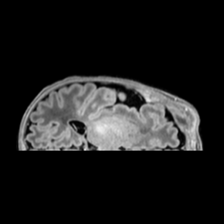

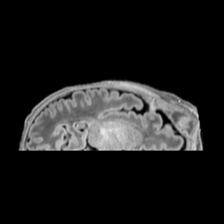

In [9]:
from torchvision.transforms import functional as F

slice1 = ds_1['train'].with_format("torch")[0]['slice1']
slice2 = ds_1['train'].with_format("torch")[0]['slice2']
label = ds_1['train'].with_format("torch")[0]['label']

display(F.to_pil_image(slice1))
F.to_pil_image(slice2)

latest, test

In [1]:
import utils as ut

ds_folds = ut.siamese_noise_dataset_fold_range(test_size=0.2, noise_size=1, n_splits=5)

2024-10-29 10:53:53.249327: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-29 10:53:53.282040: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-29 10:53:53.282062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-29 10:53:53.283148: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-29 10:53:53.289271: I tensorflow/core/platform/cpu_feature_guar

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


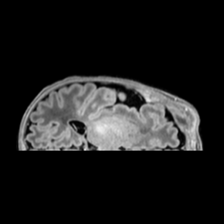

In [2]:
im = ds_folds[0]['train']['slice1'][0]
ds_folds[0]['train']['slice1'][0]

In [24]:
ut.add_noise_range(im, size=10)

IndexError: list index out of range